In [1]:
%matplotlib widget

In [2]:
from pathlib import Path
from urllib import request

from astropy.io import fits
import numpy as np

import matplotlib.pyplot as plt

from ppxf.ppxf import ppxf, robust_sigma
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from ppxf.ppxf import losvd_rfft, rebin

import pandas as pd

In [3]:
def clip_outliers(galaxy, bestfit, mask):
    """
    Repeat the fit after clipping bins deviants more than 3*sigma in relative
    error until the bad bins don't change any more. This function uses eq.(34)
    of Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C
    """
    while True:
        scale = galaxy[mask] @ bestfit[mask]/np.sum(bestfit[mask]**2)
        resid = scale*bestfit[mask] - galaxy[mask]                   #Evaluate the residuals and the dispersion of them  
        err = robust_sigma(resid, zero=1)
        ok_old = mask
        mask = np.abs(bestfit - galaxy) < 3*err
        if np.array_equal(mask, ok_old):
            break
            
    return mask

def ppxf_fit_and_clean(templates, galaxy, velscale, start, mask0, lam, lam_temp, plot=True, quiet=False):
    """
    This is a simple pPXF wrapper. It perform two pPXF fits: the first one
    serves to estimate the scatter in the spectrum and identify the outlier
    pixels. The second fit uses the mask obtained from the first fit to exclude
    the outliers. The general approach used in this function is described in
    Sec.6.5 of Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C
    """
    mask = mask0.copy()     #Initial mask 
    pp = ppxf(templates, galaxy, np.ones_like(galaxy), velscale, start,      #Fit without the mask
              moments=2, degree=4, mdegree=-1, lam=lam, lam_temp=lam_temp,
              mask=mask, quiet=quiet)              

    if plot:
        plt.figure(figsize=(20, 3))
        plt.subplot(121)
        pp.plot()
        plt.title("Initial pPXF fit before outliers removal")

    mask = clip_outliers(galaxy, pp.bestfit, mask)

    # Add clipped pixels to the original masked emission lines regions and repeat the fit
    mask &= mask0     #To mask also the outliers together with the emission lines
    pp = ppxf(templates, galaxy, np.ones_like(galaxy), velscale, start,
              moments=2, degree=4, mdegree=-1, lam=lam, lam_temp=lam_temp,
              mask=mask, quiet=quiet)
    
    pp.optimal_template = templates.reshape(templates.shape[0], -1) @ pp.weights #Combined weighted templates to obtain the best template
    
    resid = (pp.galaxy - pp.bestfit)[pp.goodpixels]
    pp.sn = np.nanmedian(pp.galaxy[pp.goodpixels])/robust_sigma(resid)  #S/N of the residual spectrum (after the fit), only of the good pixels

    if plot:
        plt.subplot(122)
        pp.plot()
        plt.title("pPXF fit after outliers removal")

    return pp

def process_ppxf_results(pp, gas_names, spectrum_name="spectrum", output_dir="./"):
    """
    Automatizza l'elaborazione dei risultati PPXF
    
    Parameters:
    -----------
    pp : oggetto PPXF con risultati del fit
    gas_names : list, nomi delle righe/doppietti dal fit PPXF
    spectrum_name : str, nome base per i file di output
    output_dir : str, directory di output
    
    Returns:
    --------
    dict con i 3 DataFrame creati
    """
    
    # Configurazione doppietti - definisce come separare le righe
    doublet_config = {
        # Nome nel fit PPXF : [nome_riga_blu, nome_riga_rossa, rapporto_blu:rossa]
        '[OIII]5007_d': ['[OIII]4959', '[OIII]5007', '1:3'],  
        '[NII]6583_d': ['[NII]6548', '[NII]6583', '1:3'],       
        '[OI]6300_d': ['[OI]6300', '[OI]6364', '3:1'],        #blu forte, rosso debole (caso speciale)
     #   '[SII]6731_d1': '[SII]6716',
     #   '[SII]6731_d2': '[SII]6731'
    }
    
    def separate_doublet(flux_total, error_total, ratio_type):
        if ratio_type == '1:3':  
            flux_blue = flux_total * (1/4)
            flux_red = flux_total * (3/4)
            error_blue = error_total * (1/4)
            error_red = error_total * (3/4)
        elif ratio_type == '3:1':  
            flux_blue = flux_total * (3/4)
            flux_red = flux_total * (1/4)
            error_blue = error_total * (3/4)
            error_red = error_total * (1/4)
        else:
            raise ValueError(f"Ratio type {ratio_type} not supported")
        
        return flux_blue, flux_red, error_blue, error_red
    
    # 2. DataFrame con righe separate  
    expanded_names = []
    expanded_fluxes = []
    expanded_errors = []
    
    for i, name in enumerate(gas_names):
        flux = pp.gas_flux[i]
        error = pp.gas_flux_error[i]
        
        if name in doublet_config:
            config = doublet_config[name]
            blue_name, red_name, ratio = config

            flux_blue, flux_red, error_blue, error_red = separate_doublet(flux, error, ratio)
                
            expanded_names.extend([blue_name, red_name])
            expanded_fluxes.extend([flux_blue, flux_red])
            expanded_errors.extend([error_blue, error_red])
            
        else:
            expanded_names.append(name)
            expanded_fluxes.append(flux)
            expanded_errors.append(error)
    
    df_expanded = pd.DataFrame({
        'Name': expanded_names,
        'Flux': expanded_fluxes,
        'Error_flux': expanded_errors})
    
    # Salva i file CSV
    output_files = {'expanded': f"{output_dir}/{spectrum_name}_gas_exp.csv", }
    df_expanded.to_csv(output_files['expanded'], index=False)

In [4]:
sps_name = 'emiles'
ppxf_dir = Path(lib.__file__).parent
basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename
if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)

C:\Users\ISAFA\anaconda3\Lib\site-packages\capfit\capfit.py:799: RuntimeWarning: invalid value encountered in scalar divide
  ratio = actred/prered


 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 3.726; DOF: 1952; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 1.798; DOF: 1886; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
 Best Fit:       Vel     sigma
 comp.  0:       499         1
 comp.  1:       521         1
 comp.  2:      -138        58
chi2/DOF: 1.434; DOF: 2262; degree = 7; mdegree = 0
method = capfit; Jac calls: 17; Func calls: 131; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 7/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component        

C:\Users\ISAFA\anaconda3\Lib\site-packages\capfit\capfit.py:799: RuntimeWarning: invalid value encountered in scalar divide
  ratio = actred/prered


 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 0.8500; DOF: 1903; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
 Best Fit:       Vel     sigma
 comp.  0:       -59         1
 comp.  1:       -15        10
 comp.  2:       125       302
chi2/DOF: 0.6202; DOF: 2262; degree = 7; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 46; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 9/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1                Hgamma      0.000       3.7     -15    10
Comp:  1                 Hbeta      2.203       2.4

C:\Users\ISAFA\anaconda3\Lib\site-packages\capfit\capfit.py:799: RuntimeWarning: invalid value encountered in scalar divide
  ratio = actred/prered


 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 0.03385; DOF: 1952; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
 Best Fit:       Vel     sigma
 comp.  0:       311        81
chi2/DOF: 0.02486; DOF: 1904; degree = 4; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/150
Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
 Best Fit:       Vel     sigma
 comp.  0:       553      1000
 comp.  1:       -37        22
 comp.  2:       -35        38
chi2/DOF: 0.02735; DOF: 2262; degree = 7; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 37; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 9/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component   

C:\Users\ISAFA\anaconda3\Lib\site-packages\capfit\capfit.py:799: RuntimeWarning: invalid value encountered in scalar divide
  ratio = actred/prered


 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 0.2534; DOF: 1952; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 0.1774; DOF: 1910; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
 Best Fit:       Vel     sigma
 comp.  0:      -580       198
 comp.  1:       -57        28
 comp.  2:       -46        61
chi2/DOF: 0.1274; DOF: 2262; degree = 7; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 37; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 12/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component      

C:\Users\ISAFA\anaconda3\Lib\site-packages\capfit\capfit.py:799: RuntimeWarning: invalid value encountered in scalar divide
  ratio = actred/prered


 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 0.3512; DOF: 1952; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
 Best Fit:       Vel     sigma
 comp.  0:        20       180
chi2/DOF: 0.2530; DOF: 1921; degree = 4; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/150
Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
 Best Fit:       Vel     sigma
 comp.  0:        12       108
 comp.  1:       -54        50
 comp.  2:      -102       120
chi2/DOF: 0.1722; DOF: 2262; degree = 7; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 37; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 10/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component      

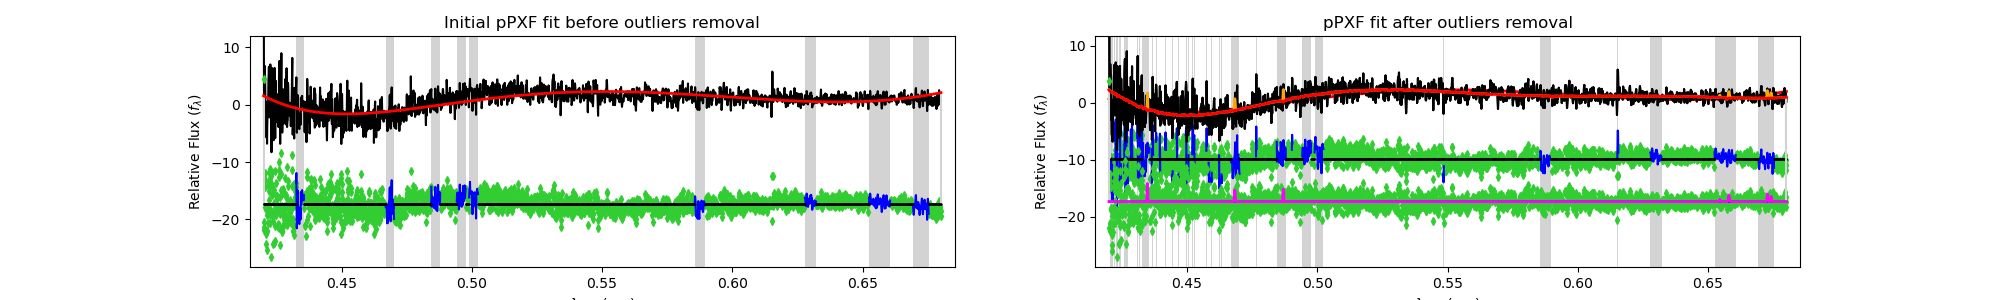

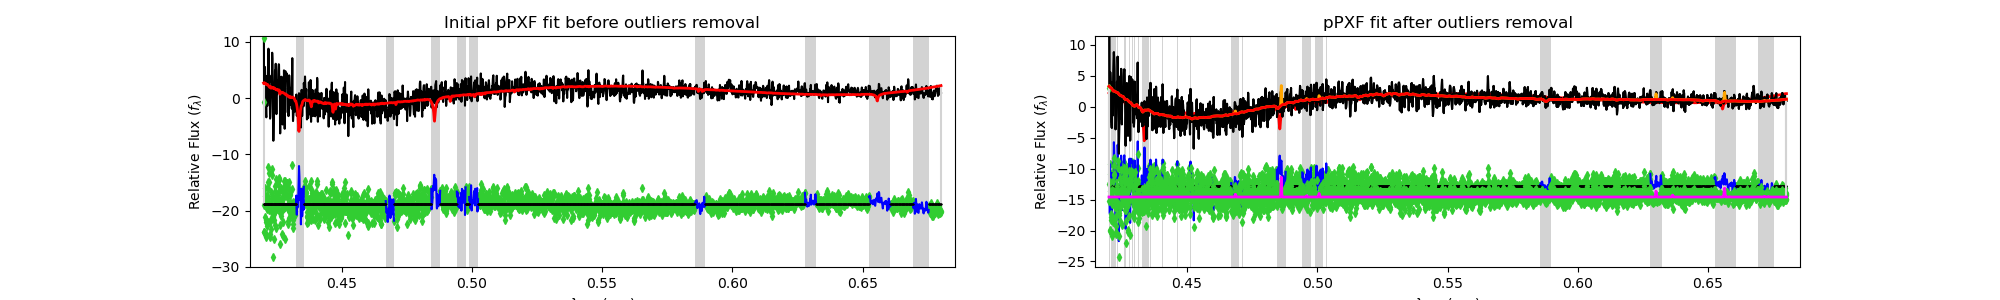

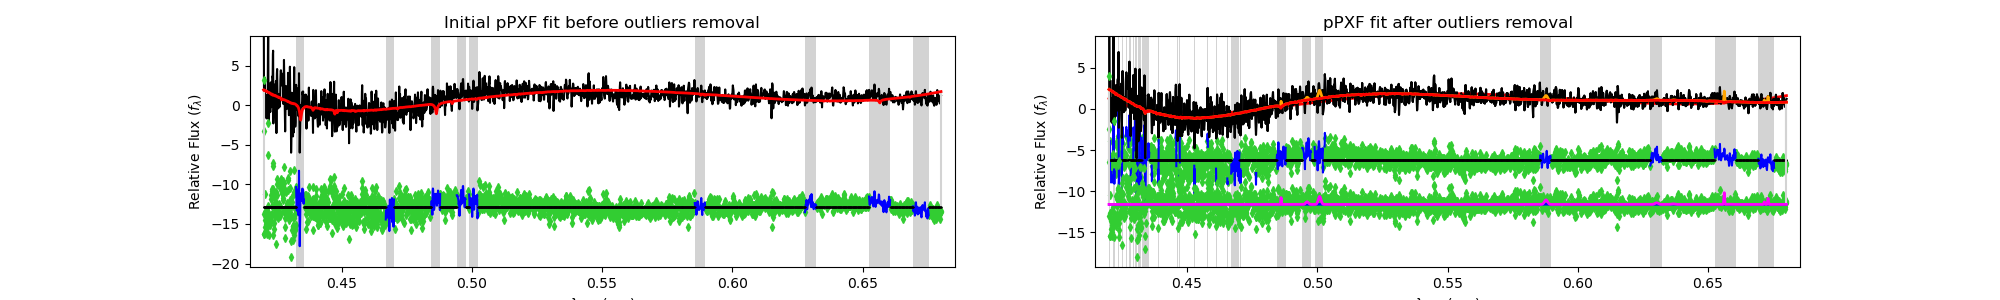

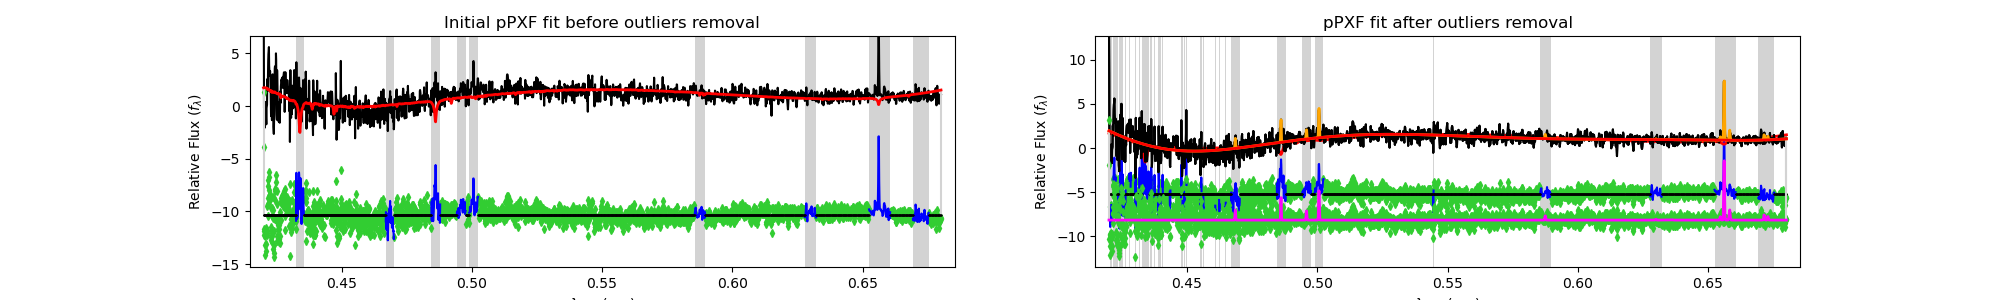

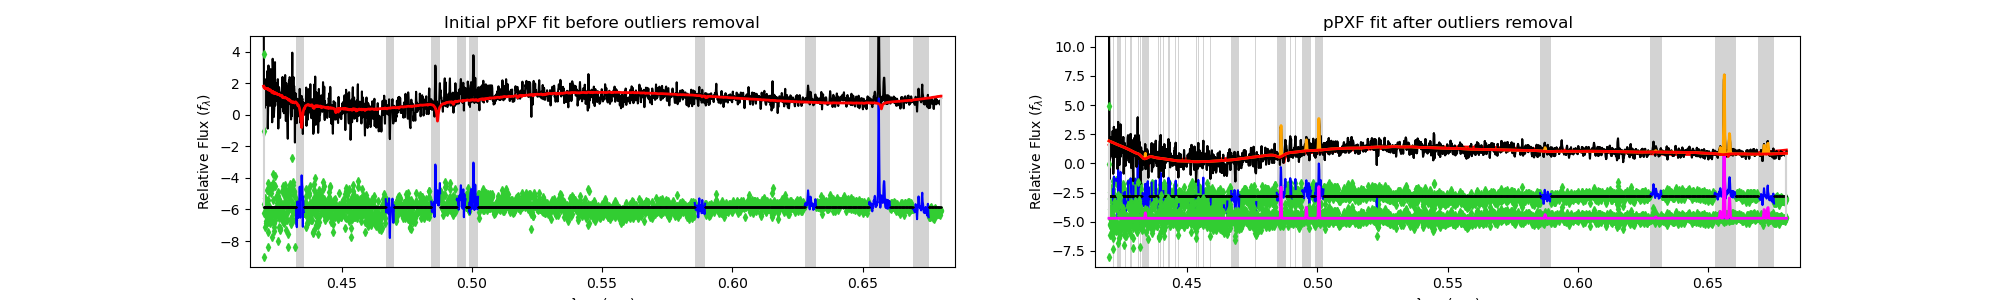

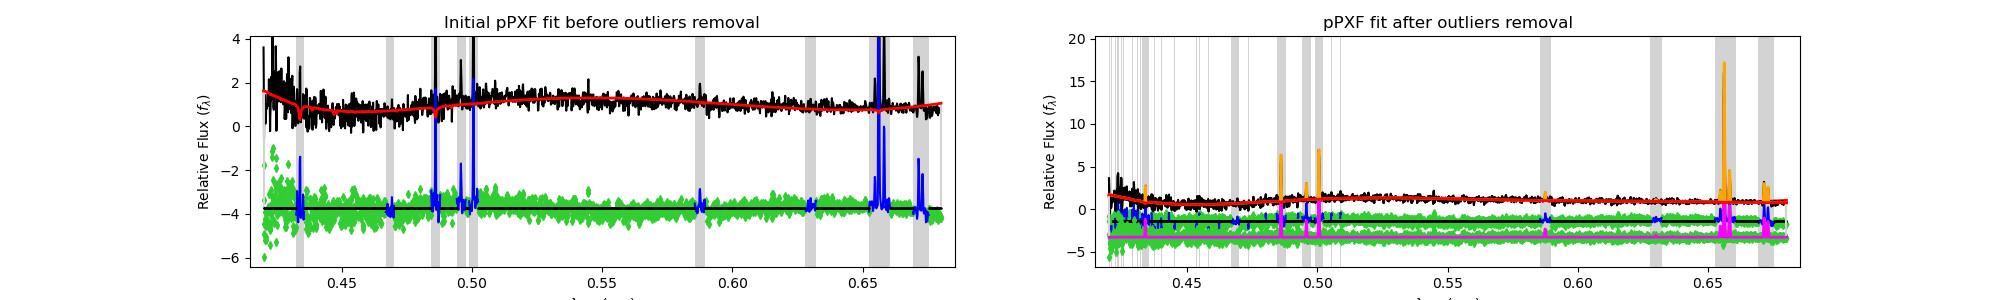

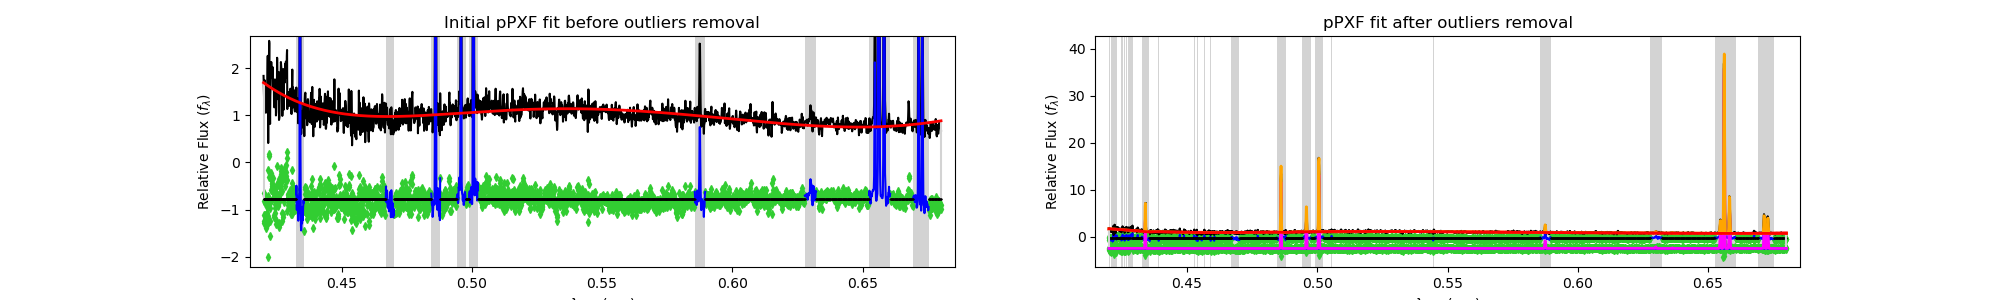

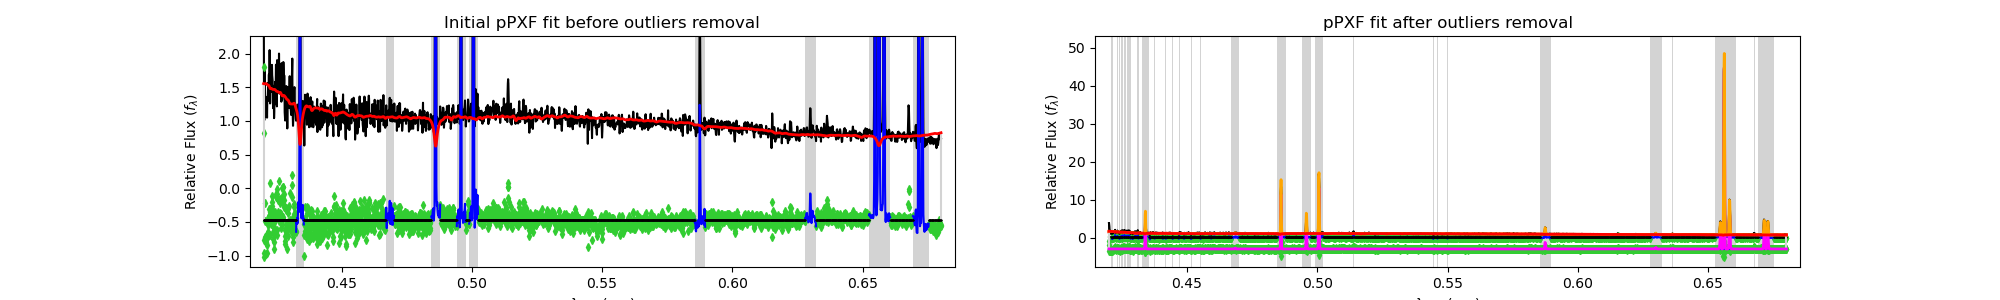

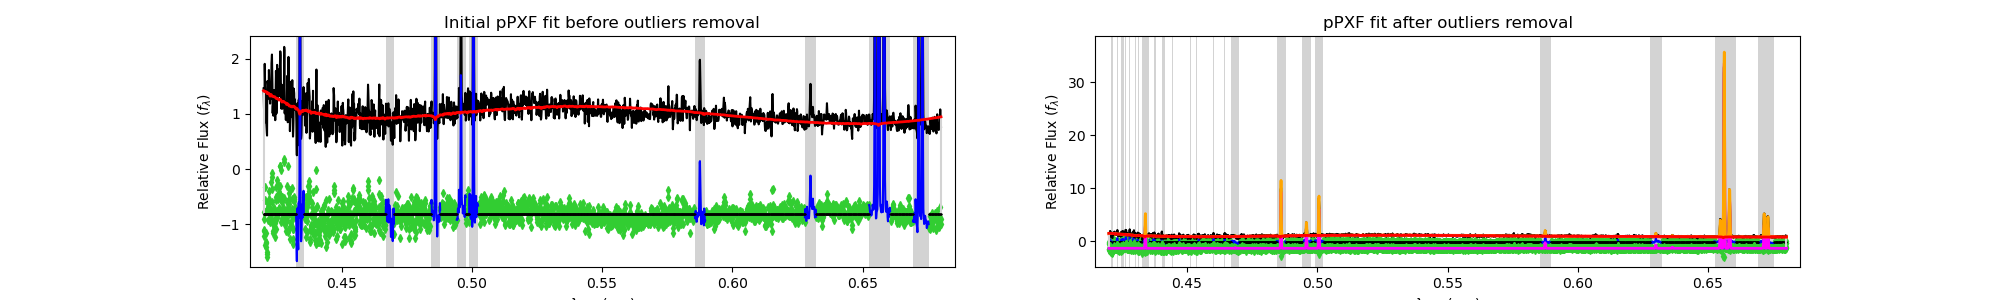

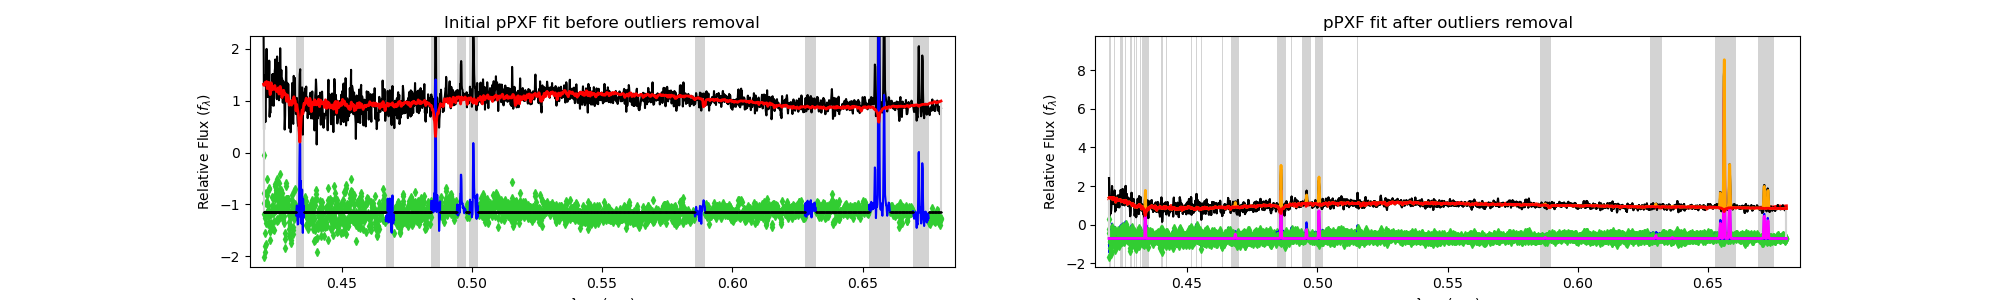

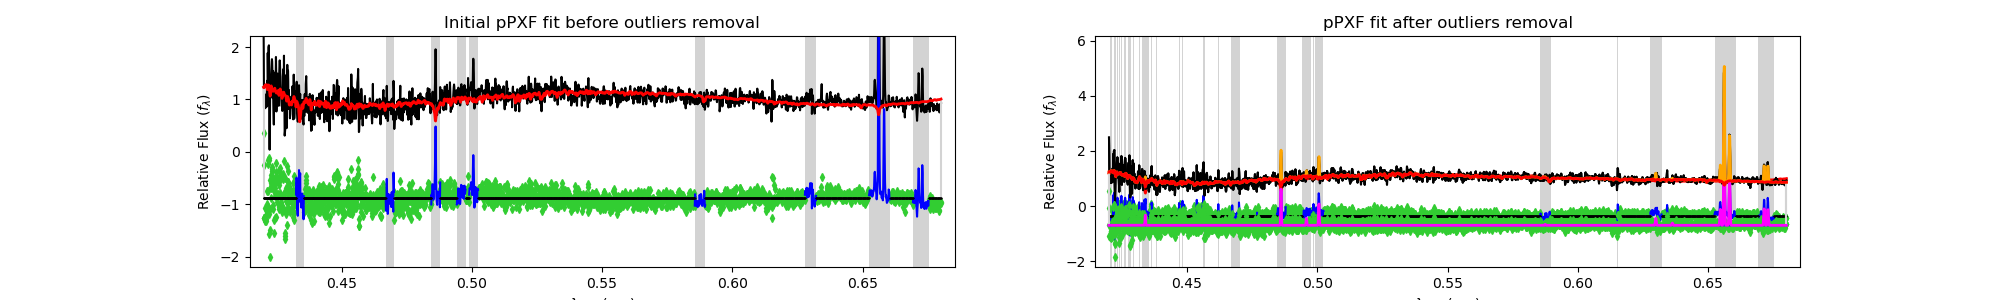

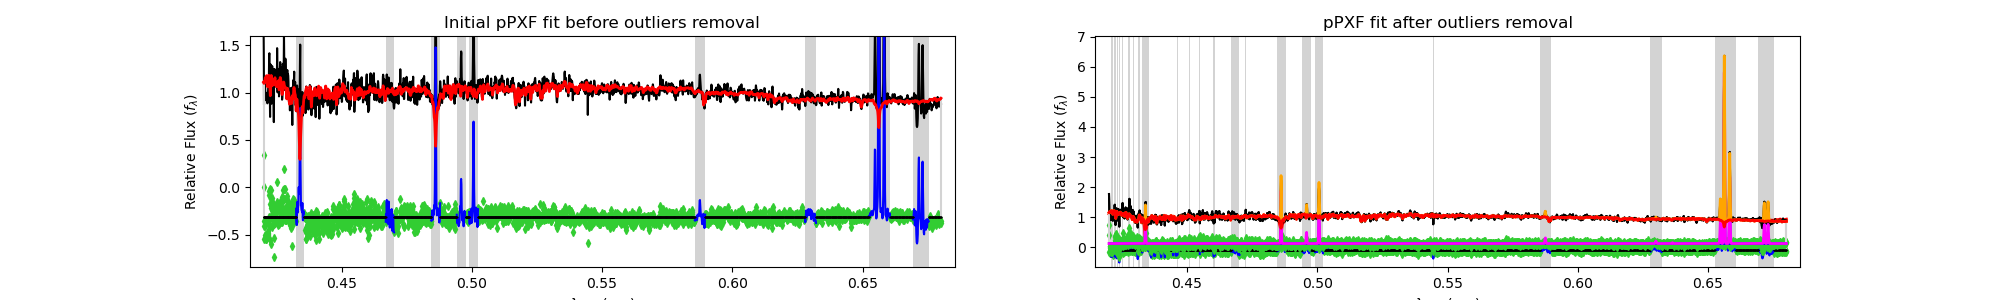

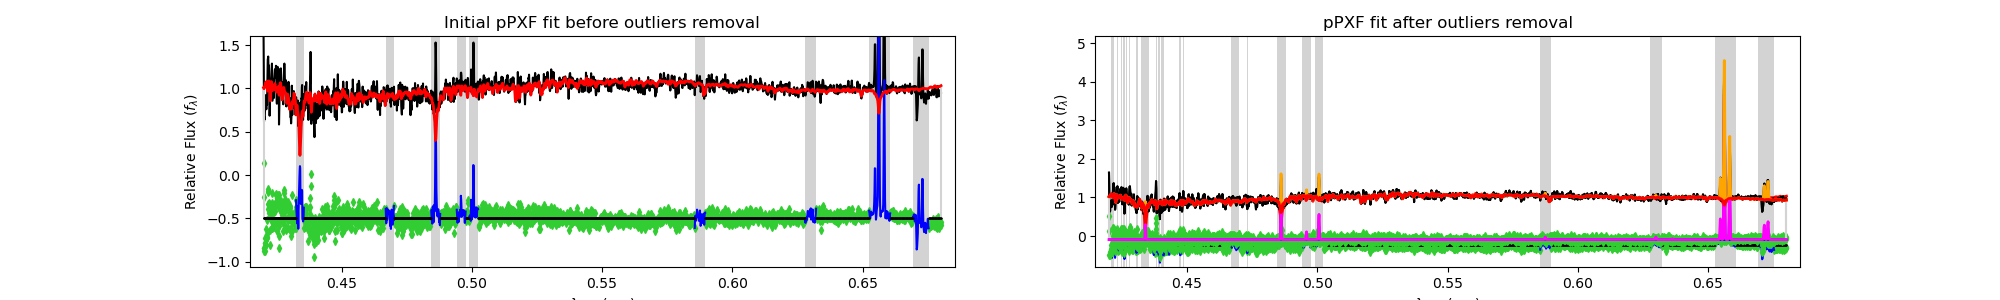

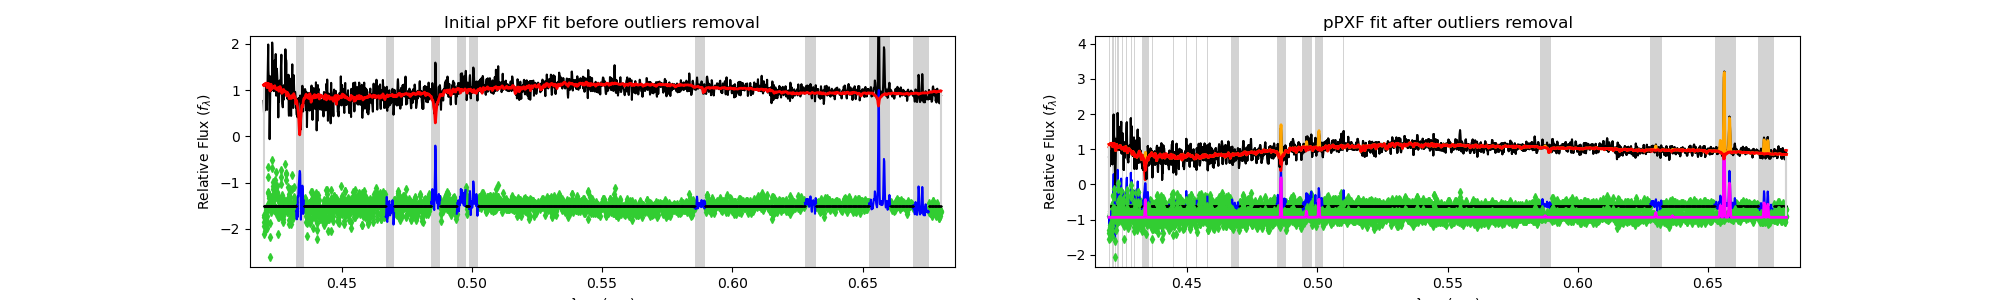

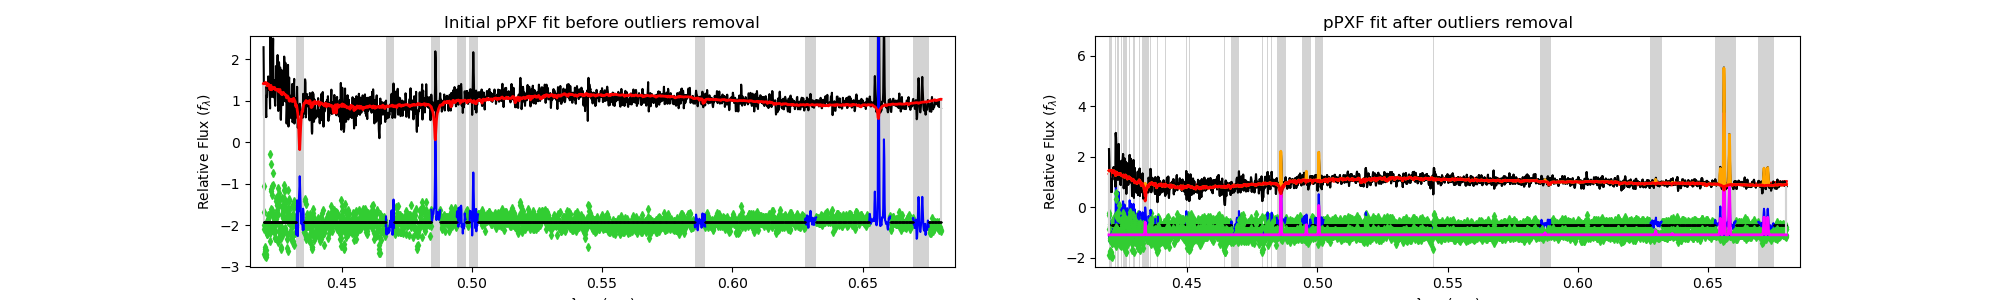

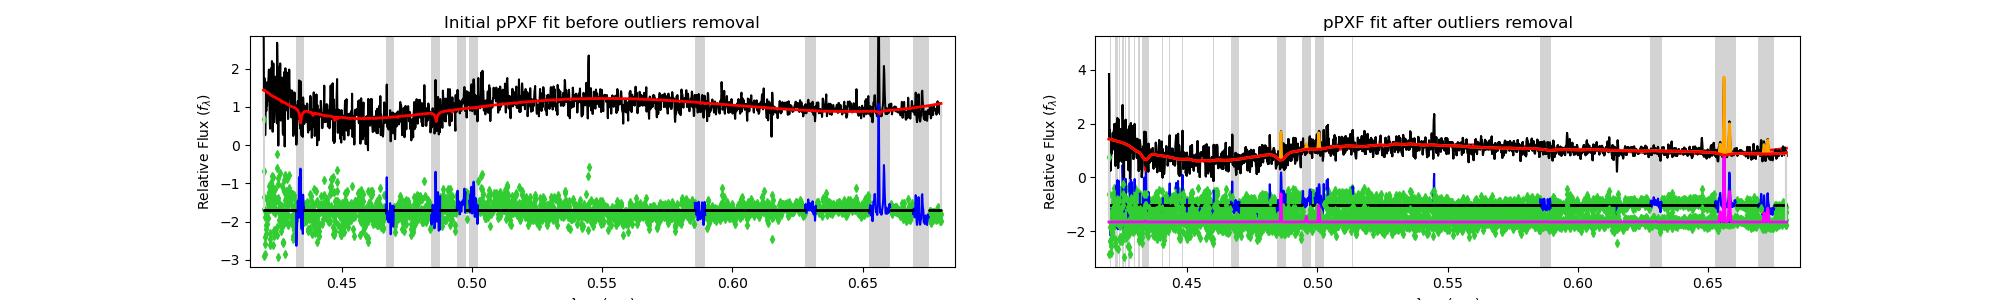

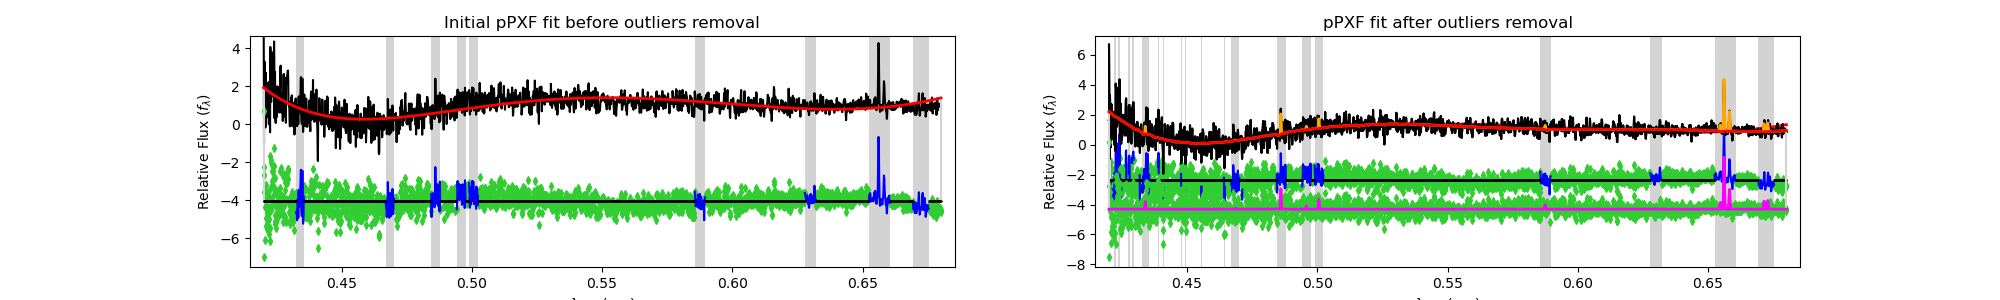

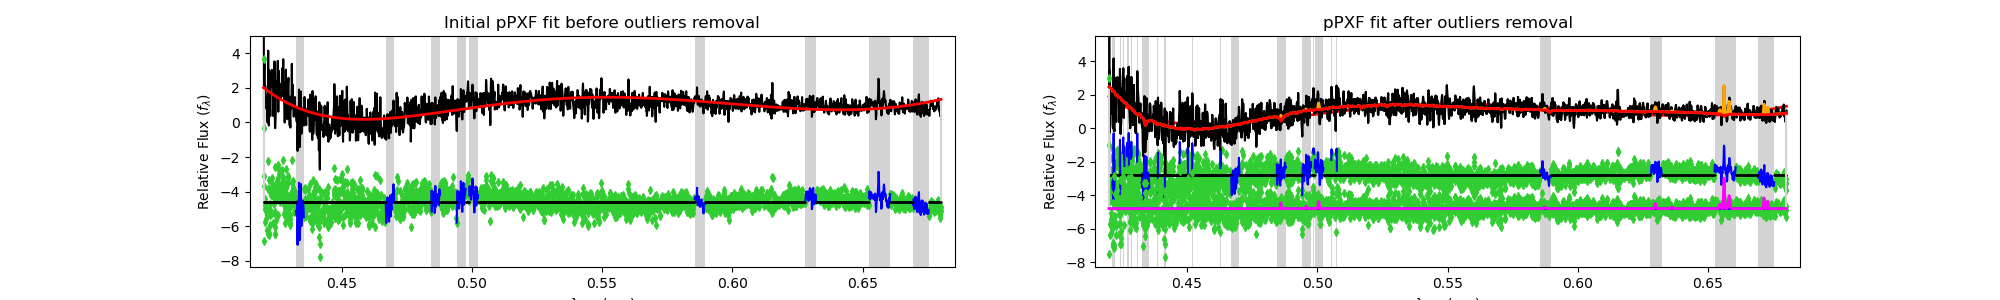

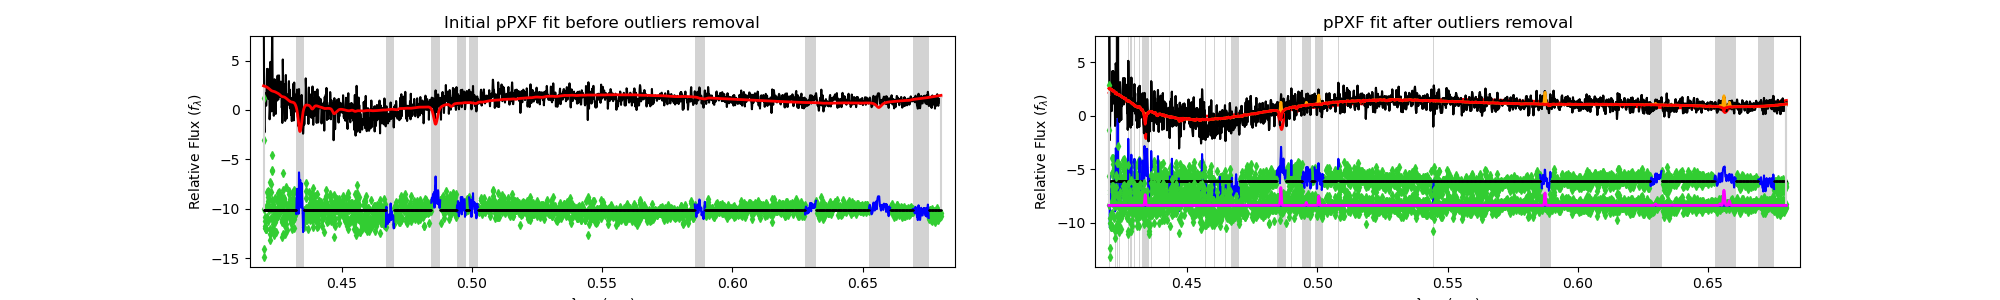

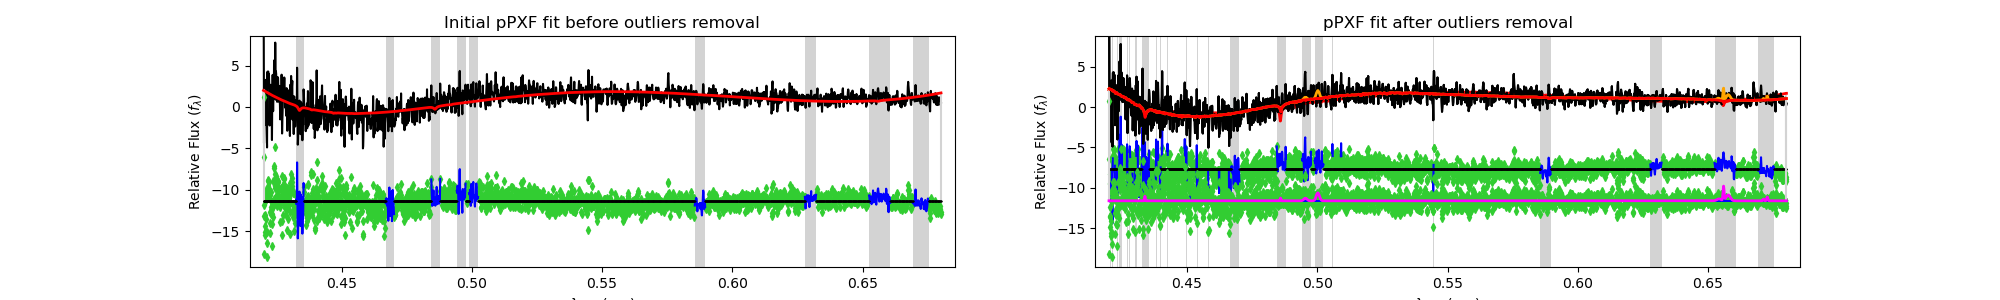

In [5]:
R = 2000 #risoluzione FORS2
c = 299792.458  # speed of light in km/s
tie_balmer = False  #Set this to ``True`` to tie the Balmer lines according to a theoretical decrement
limit_doublets = True #Set this to True to limit the ratio of the [OII] and [SII] doublets to the ranges allowed by atomic physics.
z = 0.0238 
for i in range(1, 21):
    wv, flux, error = np.loadtxt(f"Spectrum_{i}.txt", unpack = True) 
    wv_rf = wv/(1+z)
    flux_rf = flux*(1+z)
    error_rf = error*(1+z)

    velscale = np.min(c*np.diff(np.log(wv_rf))) #velocity scale to quantify the galaxy velocity dispersion
    flux_rf_rebin, wv_rf_rebin, velscale = util.log_rebin(wv_rf, flux_rf, velscale = velscale) #We need to rebin the flux and the other things to work with the code
    galaxy = flux_rf_rebin/np.median(flux_rf_rebin) #Normalization
    error_rf_rebin, wv_rf_rebin, velscale = util.log_rebin(wv_rf, error_rf, velscale = velscale)
    error_gal = error_rf_rebin/np.median(error_rf_rebin)

    fwhm_gal = (wv_rf/R)
    fwhm_gal_dic = {"lam": wv_rf, "fwhm": fwhm_gal}
    sps = lib.sps_lib(filename, velscale, fwhm_gal_dic)

    reg_dim = sps.templates.shape[1:]
    stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)
    ln_lam_pop_stars = sps.ln_lam_temp

    mask = (np.exp(ln_lam_pop_stars) > (np.min(wv_rf)-500))*(np.exp(ln_lam_pop_stars) < (np.max(wv_rf)+500))
    stars_templates = stars_templates[mask, :]
    lam_temp = sps.lam_temp
    lam_temp = lam_temp[mask]

    stars_templates /= np.median(stars_templates, axis=0)
    ln_lam_pop_stars = ln_lam_pop_stars[mask]

    lam_range_temp = np.exp(sps.ln_lam_temp[[0, -1]])
    mask0 = util.determine_mask(wv_rf_rebin, lam_range_temp, 0, width=1000)

    start = [20, 180.] 
    pp_stars = ppxf_fit_and_clean(stars_templates, galaxy, velscale, start, mask0, np.exp(wv_rf_rebin), lam_temp)

    lam_range_gal = np.array([np.min(wv_rf), np.max(wv_rf)]) #Range of wv for the data
    gas_templates, gas_names, line_wave = util.emission_lines(
    ln_lam_pop_stars, lam_range_gal, fwhm_gal_dic, tie_balmer=tie_balmer,
    limit_doublets=limit_doublets)

    templates = np.column_stack([stars_templates, gas_templates])
    start = [20, 180.] 
    results = [pp_stars.sol[0], pp_stars.sol[1]]
    n_temps = stars_templates.shape[1]
    n_forbidden = np.sum(["[" in a for a in gas_names])  # forbidden lines contain "[*]"
    n_balmer = len(gas_names) - n_forbidden

    component = [0]*n_temps + [1]*n_balmer + [2]*n_forbidden #When fitting more than one kinematic component, this keyword should contain the component number of each input template. 
                                                         #In principle, every template can belong to a different kinematic component.

    gas_component = np.array(component) > 0  # gas_component=True for gas templates
                                         #Boolean vector, of the same size as component, set to True where the given component describes a gas emission line. 
                                         #If given, pPXF provides the pp.gas_flux and pp.gas_flux_error in output.
    moments = [2, 2, 2]
    start = [results, start, start]
    gas_reddening = 0 if tie_balmer else None

    pp = ppxf(templates, galaxy, error_gal, velscale, start, moments=moments,     #We put what we had set here to do the ppxf procedure
          degree=7, mdegree=-1, lam=np.exp(wv_rf_rebin), lam_temp=np.exp(ln_lam_pop_stars), component=component,
          gas_component=gas_component, gas_names=gas_names,
          gas_reddening=gas_reddening)

    pp.plot()

    d1 = {'Name': gas_names, 'Flux': pp.gas_flux, 'Error flux': pp.gas_flux_error}
    df1 = pd.DataFrame(data=d1)
    df1.to_csv(f"Spectrum_{i}_gas_ppxf.csv", index= False)

    process_ppxf_results(pp, gas_names, spectrum_name=f"Spectrum_{i}", output_dir="./")

    d3 = {'Component': [0, 1, 2], 'Vel': [pp.sol[0][0], pp.sol[1][0], pp.sol[2][0]], 'Sigma': [pp.sol[0][1], pp.sol[1][1], pp.sol[2][1]]}
    df3 = pd.DataFrame(data=d3)
    df3.to_csv(f"Spectrum_{i}_kin.csv", index= False)

    read = pd.read_csv(f"Spectrum_{i}_gas_ppxf.csv")
    print(read)
    read2 = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    print(read2)
    